In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#upload Dataset & cleaned
df = pd.read_csv('/content/Zomato_Master_Cleaned.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant_ID         9551 non-null   int64  
 1   Restaurant_Name       9551 non-null   object 
 2   Country_Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality_Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average_Cost_for_two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has_Table_booking     9551 non-null   object 
 13  Has_Online_delivery   9551 non-null   object 
 14  Is_delivering_now     9551 non-null   object 
 15  Switch_to_order_menu 

In [ ]:
#Checking for Null Values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#fill Nan Values
df.fillna('NA',inplace=True)

In [ ]:
#check for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#for unique values
df.nunique()

,0
Restaurant_ID,9551
Restaurant_Name,7432
Country_Code,15
City,141
Address,8905
Locality,1208
Locality_Verbose,1256
Longitude,8120
Latitude,8677
Cuisines,1826


In [ ]:
#checking for columns
df.columns

Index(['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address',
       'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average_Cost_for_two', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu',
       'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text',
       'Votes'],
      dtype='object')

In [ ]:
#for change data type category in one query

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')


In [ ]:
#Which cities have the highest number of restaurants?
#Do restaurants that offer online delivery have better ratings than those that don't?
#What are the most popular cuisines?

In [ ]:
#Which cities have the highest number of restaurants?

city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')


top_cities = city_stats.sort_values(by='Restaurant_Count', ascending=False).head(10)

top_cities



/tmp/ipykernel_10176/143030239.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')


,City,Country_Code,Restaurant_Count
1335,New Delhi,1,5473
750,Gurgaon,1,1118
1350,Noida,1,1080
645,Faridabad,1,251
720,Ghaziabad,1,25
1050,Lucknow,1,21
765,Guwahati,1,21
30,Ahmedabad,1,21
255,Bhubaneshwar,1,21
75,Amritsar,1,21


/tmp/ipykernel_10176/1534698736.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



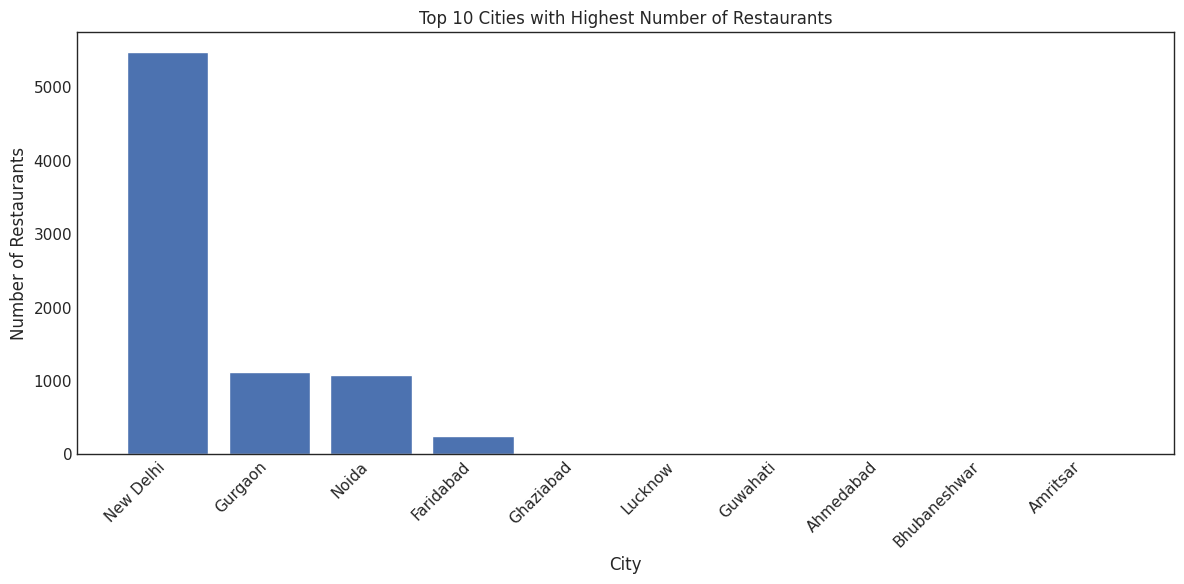

In [ ]:
import matplotlib.pyplot as plt

# Count restaurants city-wise
city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')

# Top 10 cities
top_cities = city_stats.sort_values(by='Restaurant_Count', ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top_cities['City'], top_cities['Restaurant_Count'])

# Labels and title
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.title('Top 10 Cities with Highest Number of Restaurants')

# Rotate labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Do restaurants that offer online delivery have better ratings than those that don't?
delivery_rating = df.groupby('Has_Online_delivery')['Aggregate_rating'].mean().reset_index()
delivery_rating

/tmp/ipykernel_10176/2564970970.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_rating = df.groupby('Has_Online_delivery')['Aggregate_rating'].mean().reset_index()


,Has_Online_delivery,Aggregate_rating
0,No,2.465296
1,Yes,3.248837


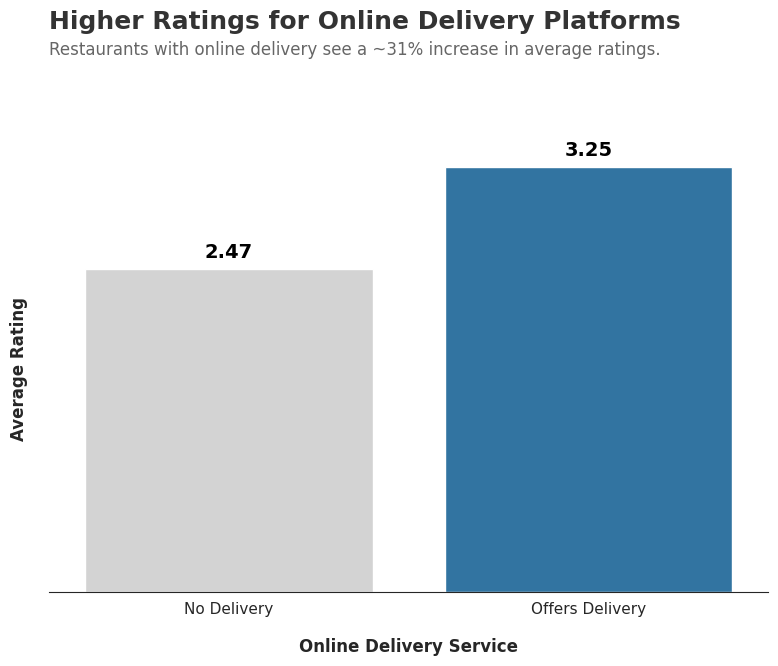

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setting the visual style
sns.set_style("white") # Clean background
plt.figure(figsize=(8, 7))

# 2. Colors - Combination of Corporate Blue and Light Grey
colors = ["#D3D3D3", "#1f77b4"]

# 3. Creating the bar plot
ax = sns.barplot(x='Has_Online_delivery', y='Aggregate_rating',
                 data=delivery_rating, palette=colors, hue='Has_Online_delivery', legend=False)

# 4. Adding styled data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                fontsize=14, fontweight='bold', color='black',
                xytext=(0, 8), textcoords='offset points')

# 5. Professional Title and Sub-title
plt.text(-0.5, 4.3, 'Higher Ratings for Online Delivery Platforms', fontsize=18, fontweight='bold', color='#333333')
plt.text(-0.5, 4.1, 'Restaurants with online delivery see a ~31% increase in average ratings.', fontsize=12, color='#666666')

# 6. Axis labels and formatting
plt.xlabel('Online Delivery Service', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Average Rating', fontsize=12, fontweight='bold', labelpad=15)
plt.xticks(ticks=[0, 1], labels=['No Delivery', 'Offers Delivery'], fontsize=11)

# Removing unnecessary spines and y-axis ticks for a cleaner look
sns.despine(top=True, right=True, left=True)
plt.yticks([])

plt.tight_layout()
plt.show()


In [ ]:
#What are the most popular cuisines?
most_popular = df.groupby('Cuisines')['Votes'].sum().reset_index()
top = most_popular.sort_values(by='Votes', ascending=False).head(10)
top

/tmp/ipykernel_10176/2106421693.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  most_popular = df.groupby('Cuisines')['Votes'].sum().reset_index()


,Cuisines,Votes
1514,"North Indian, Mughlai",53747
1306,North Indian,46241
1329,"North Indian, Chinese",42012
331,Cafe,30657
497,Chinese,21925
1520,"North Indian, Mughlai, Chinese",20115
828,Fast Food,17852
1700,South Indian,16433
1288,"Mughlai, North Indian",15275
1031,Italian,14799


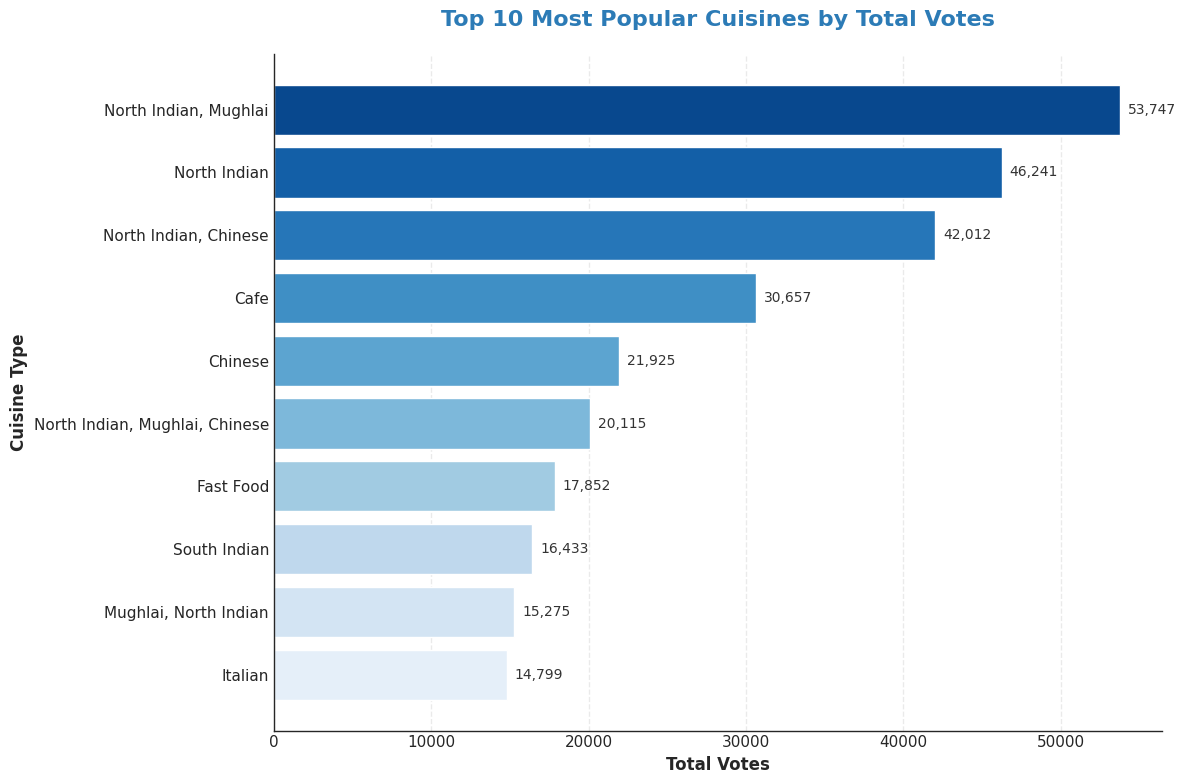

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dummy Data (Aap apne DataFrame 'df' se replace karein)
cuisines = ['North Indian, Mughlai', 'North Indian', 'North Indian, Chinese', 'Cafe', 'Chinese',
            'North Indian, Mughlai, Chinese', 'Fast Food', 'South Indian', 'Mughlai, North Indian', 'Italian']
votes = [53747, 46241, 42012, 30657, 21925, 20115, 17852, 16433, 15275, 14799]

# Figure setting
plt.figure(figsize=(12, 8))

# Gradient color palette (Blues_r use kiya hai image se match karne ke liye)
palette = sns.color_palette("Blues_r", len(cuisines))

# Horizontal Bar Plot
bars = plt.barh(cuisines, votes, color=palette)

# Chart ko sundar banane ke liye steps:
plt.gca().invert_yaxis()  # Taki highest value upar rahe
plt.title('Top 10 Most Popular Cuisines by Total Votes', fontsize=16, fontweight='bold', color='#2c7bb6', pad=20)
plt.xlabel('Total Votes', fontsize=12, fontweight='bold')
plt.ylabel('Cuisine Type', fontsize=12, fontweight='bold')

# Data Labels (Bar ke aage numbers likhne ke liye)
for i, v in enumerate(votes):
    plt.text(v + 500, i, f'{v:,}', va='center', fontsize=10, color='#333333')

# Clean layout (Borders hatane ke liye)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
#What are the top 10 most popular cuisines in international markets , and how do they compare in terms of customer engagement (Votes)?
# 1. Filter dataset for International Markets (Excluding India)
foreign_df = df[df['Country_Code'] != 1]

# 2. Group by Cuisines and calculate total engagement (Votes)
foreign_cuisines = foreign_df.groupby('Cuisines')['Votes'].sum().reset_index()

# 3. Sort and select Top 10 most popular cuisines
top_foreign_eda = foreign_cuisines.sort_values(by='Votes', ascending=False).head(10)

# 4. Display the results
print("Top 10 International Cuisines by Customer Engagement (Votes):")
print(top_foreign_eda)




Top 10 International Cuisines by Customer Engagement (Votes):
               Cuisines  Votes
6              American   7453
29     American, Burger   6371
1212            Mexican   6283
995              Indian   6068
1780  Sunda, Indonesian   5514
1031            Italian   5462
331                Cafe   5193
1668            Seafood   4150
1098     Italian, Pizza   4120
1126    Japanese, Sushi   3765


/tmp/ipykernel_10176/3598713545.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  foreign_cuisines = foreign_df.groupby('Cuisines')['Votes'].sum().reset_index()


/tmp/ipykernel_10176/4150080370.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  foreign_cuisines = foreign_df.groupby('Cuisines')['Votes'].sum().reset_index()


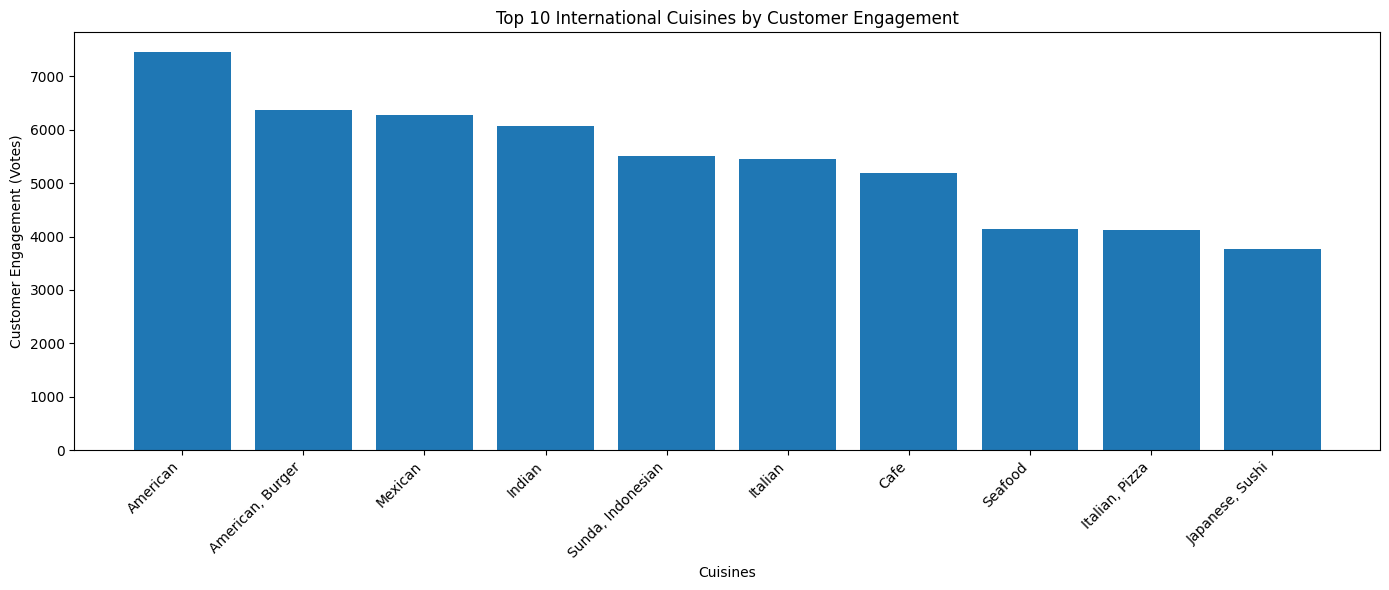

In [ ]:
import matplotlib.pyplot as plt

# 1. Filter dataset for International Markets (Excluding India)
foreign_df = df[df['Country_Code'] != 1]

# 2. Group by Cuisines and calculate total engagement (Votes)
foreign_cuisines = foreign_df.groupby('Cuisines')['Votes'].sum().reset_index()

# 3. Sort and select Top 10 most popular cuisines
top_foreign_eda = foreign_cuisines.sort_values(by='Votes', ascending=False).head(10)

# 4. Plot chart
plt.figure(figsize=(14,6))
plt.bar(top_foreign_eda['Cuisines'], top_foreign_eda['Votes'])

# Labels and Title
plt.xlabel('Cuisines')
plt.ylabel('Customer Engagement (Votes)')
plt.title('Top 10 International Cuisines by Customer Engagement')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Which cities have the highest number of restaurants?

city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')


top_cities = city_stats.sort_values(by='Restaurant_Count', ascending=False).head(10)

top_cities



/tmp/ipykernel_10176/143030239.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')


,City,Country_Code,Restaurant_Count
1335,New Delhi,1,5473
750,Gurgaon,1,1118
1350,Noida,1,1080
645,Faridabad,1,251
720,Ghaziabad,1,25
1050,Lucknow,1,21
765,Guwahati,1,21
30,Ahmedabad,1,21
255,Bhubaneshwar,1,21
75,Amritsar,1,21


              City  Country_Code  Restaurant_Count
1335     New Delhi             1              5473
750        Gurgaon             1              1118
1350         Noida             1              1080
645      Faridabad             1               251
720      Ghaziabad             1                25
1050       Lucknow             1                21
765       Guwahati             1                21
30       Ahmedabad             1                21
255   Bhubaneshwar             1                21
75        Amritsar             1                21


/tmp/ipykernel_10176/3782191007.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')


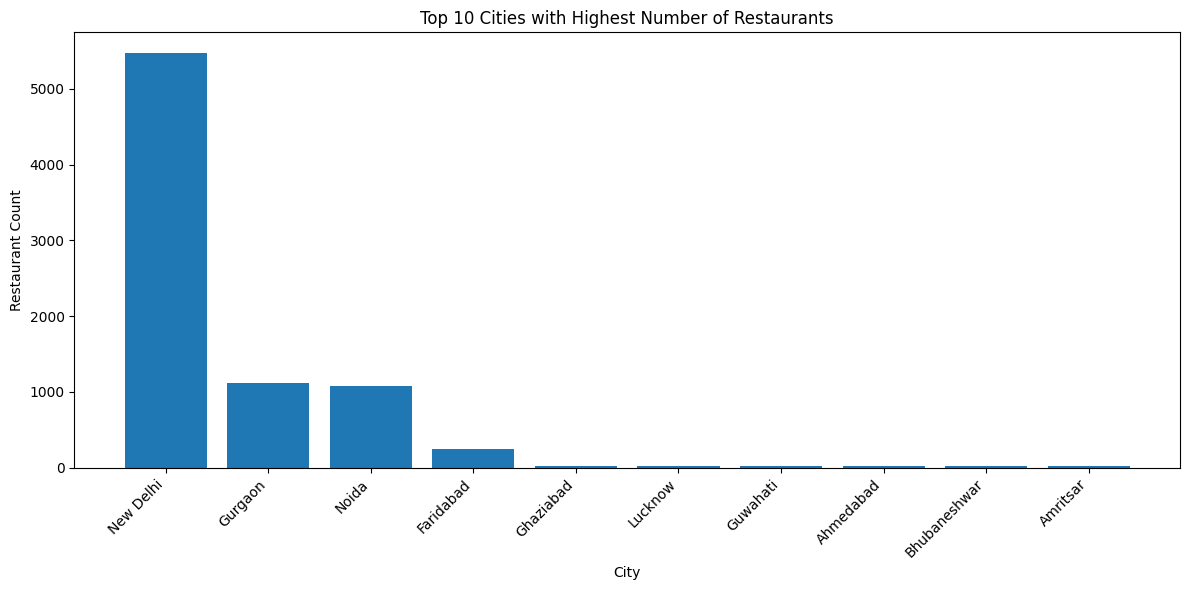

In [ ]:
import matplotlib.pyplot as plt

# Count restaurants city-wise
city_stats = df.groupby(['City', 'Country_Code']).size().reset_index(name='Restaurant_Count')

# Get top 10 cities with highest restaurants
top_cities = city_stats.sort_values(by='Restaurant_Count', ascending=False).head(10)

# Display dataframe
print(top_cities)

# Plot chart
plt.figure(figsize=(12,6))
plt.bar(top_cities['City'], top_cities['Restaurant_Count'])

# Labels and title
plt.xlabel('City')
plt.ylabel('Restaurant Count')
plt.title('Top 10 Cities with Highest Number of Restaurants')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()